# Week 3 - Day 11

# Linear Regression & Polynomial Regression

## Cooperative Tech Private Limited

### AI / ML Internship Program

---

## Student Information

**Intern:** Maryam Fatima

**Week:** 03

**Day:** 11

**Topic**

- Linear Regression
- Polynomial Regression
- Regression Evaluation Metrics

---

## Description

Day 11 introduces the first supervised machine learning regression algorithm. In this notebook, we will build and evaluate both Linear Regression and Polynomial Regression models using Scikit-Learn. We will also compare their performance using standard regression evaluation metrics and visualize the prediction results.

---

## Learning Objectives

By the end of this notebook, we will be able to:

- Understand Supervised Learning
- Understand Regression Problems
- Learn Linear Regression
- Learn Polynomial Regression
- Train Machine Learning Models
- Predict Continuous Values
- Evaluate Model Performance
- Visualize Prediction Results
- Compare Regression Algorithms

---

# What is Supervised Machine Learning?

Machine Learning is divided into several categories. One of the most widely used categories is Supervised Learning.

Supervised Learning is a type of machine learning where the algorithm learns from labeled data. This means that both the input features and the correct output values are already known during training.

The goal of supervised learning is to learn the relationship between input variables (features) and the target variable so that the model can accurately predict unseen data.

Examples include:

- Predicting house prices
- Predicting salaries
- Predicting stock prices
- Predicting sales
- Customer churn prediction
- Email spam detection

There are two main types of supervised learning:

1. Regression
2. Classification

Today we focus on Regression.

# What is Regression?

Regression is a supervised machine learning technique used when the target variable is continuous.

Instead of predicting categories like "Yes" or "No", regression predicts numerical values.

Examples include:

- House Price Prediction
- Temperature Prediction
- Salary Prediction
- Gold Price Prediction
- Car Price Prediction
- Sales Forecasting

Regression attempts to learn the relationship between independent variables (features) and a dependent variable (target).

# What is Linear Regression?

Linear Regression is the simplest regression algorithm.

It assumes a linear relationship between the input variables and the output variable.

Mathematically,

y = mx + c

Where:

- y = Target Value
- x = Feature
- m = Slope
- c = Intercept

The algorithm finds the best-fit line that minimizes prediction errors using Ordinary Least Squares (OLS).

Linear Regression is widely used because it is:

- Easy to understand
- Fast
- Interpretable
- Effective for linear relationships

Applications include:

- House Price Prediction
- Sales Prediction
- Revenue Forecasting
- Temperature Prediction

# What is Polynomial Regression?

Sometimes data does not follow a straight line.

In such cases, Linear Regression cannot accurately capture the relationship.

Polynomial Regression extends Linear Regression by introducing polynomial features such as:

x²

x³

x⁴

This allows the model to fit curved relationships instead of straight lines.

Polynomial Regression is especially useful when the relationship between variables is non-linear.

# Dataset

For this practical, we will use the California Housing Dataset available inside Scikit-Learn.

Dataset Information

Features

- MedInc
- HouseAge
- AveRooms
- AveBedrms
- Population
- AveOccup
- Latitude
- Longitude

Target

Median House Value

This dataset is commonly used for regression tasks.

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Loading Dataset

Now we will load the California Housing dataset from Scikit-Learn.

The dataset contains multiple numerical features and one continuous target variable representing the median house value.

We will convert the dataset into a Pandas DataFrame for easier exploration and analysis.

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Dataset Overview

Before building any machine learning model, it is important to understand the dataset.

We will examine:

- Number of rows
- Number of columns
- Data types
- Missing values
- Statistical summary

This helps identify any preprocessing requirements before training the model.

In [3]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)

print(df.shape)

Dataset Shape
(20640, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
Price,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


# Checking Missing Values

Missing values can negatively affect machine learning models.

Before training, we must verify whether the dataset contains any null values.

If missing values exist, they should be handled using techniques such as:

- Mean Imputation
- Median Imputation
- Mode Imputation
- Removing Rows
- Removing Columns

Fortunately, the California Housing dataset is already clean.

In [6]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is one of the most important phases of any Machine Learning project.

The purpose of EDA is to understand the dataset before training a model.

During EDA, we answer questions like:

- How many features exist?
- Which features are strongly correlated?
- Are there any outliers?
- What is the distribution of each feature?
- Which variables affect the target variable the most?

A good EDA helps us build better machine learning models.

In [7]:
# Display first five rows

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# Display last five rows

df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [9]:
# Display column names

df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

# Correlation Analysis

Correlation measures the strength of relationship between two variables.

Correlation values range from:

- +1 → Strong Positive Relationship
- 0 → No Relationship
- -1 → Strong Negative Relationship

Highly correlated features often have a strong impact on the prediction target.

We visualize correlations using a Heatmap.

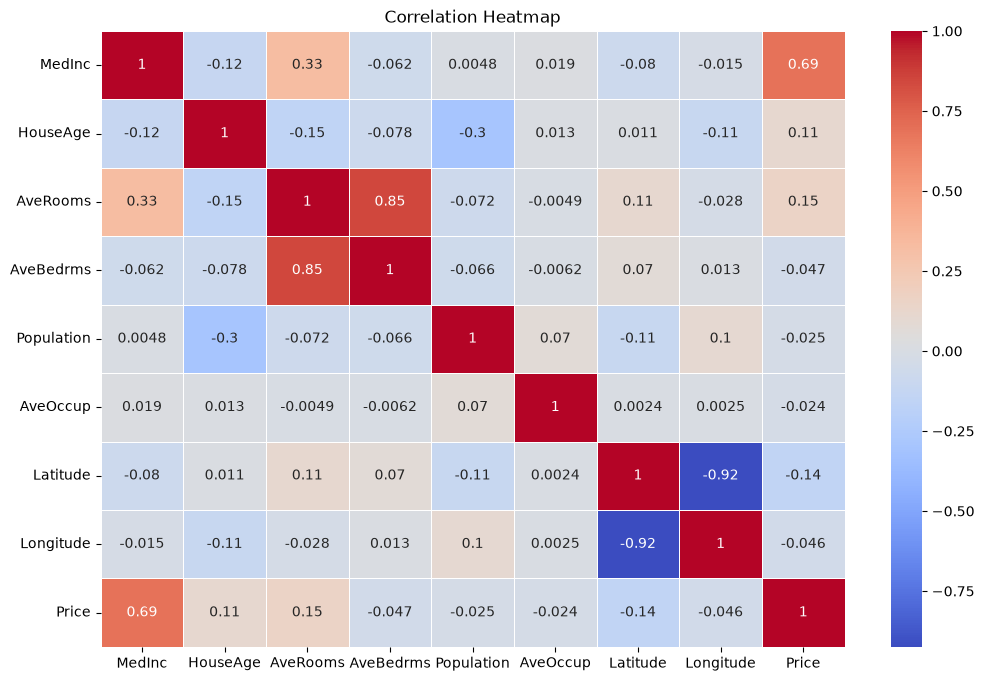

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap helps us identify relationships between features.

Positive correlation indicates that as one variable increases, the other also increases.

Negative correlation indicates the opposite.

Features with stronger correlation to the target are usually more useful for prediction.

# Feature Distribution

Before training a model, we should understand the distribution of numerical features.

Histograms help us identify:

- Normal Distribution
- Skewed Data
- Outliers
- Extreme Values

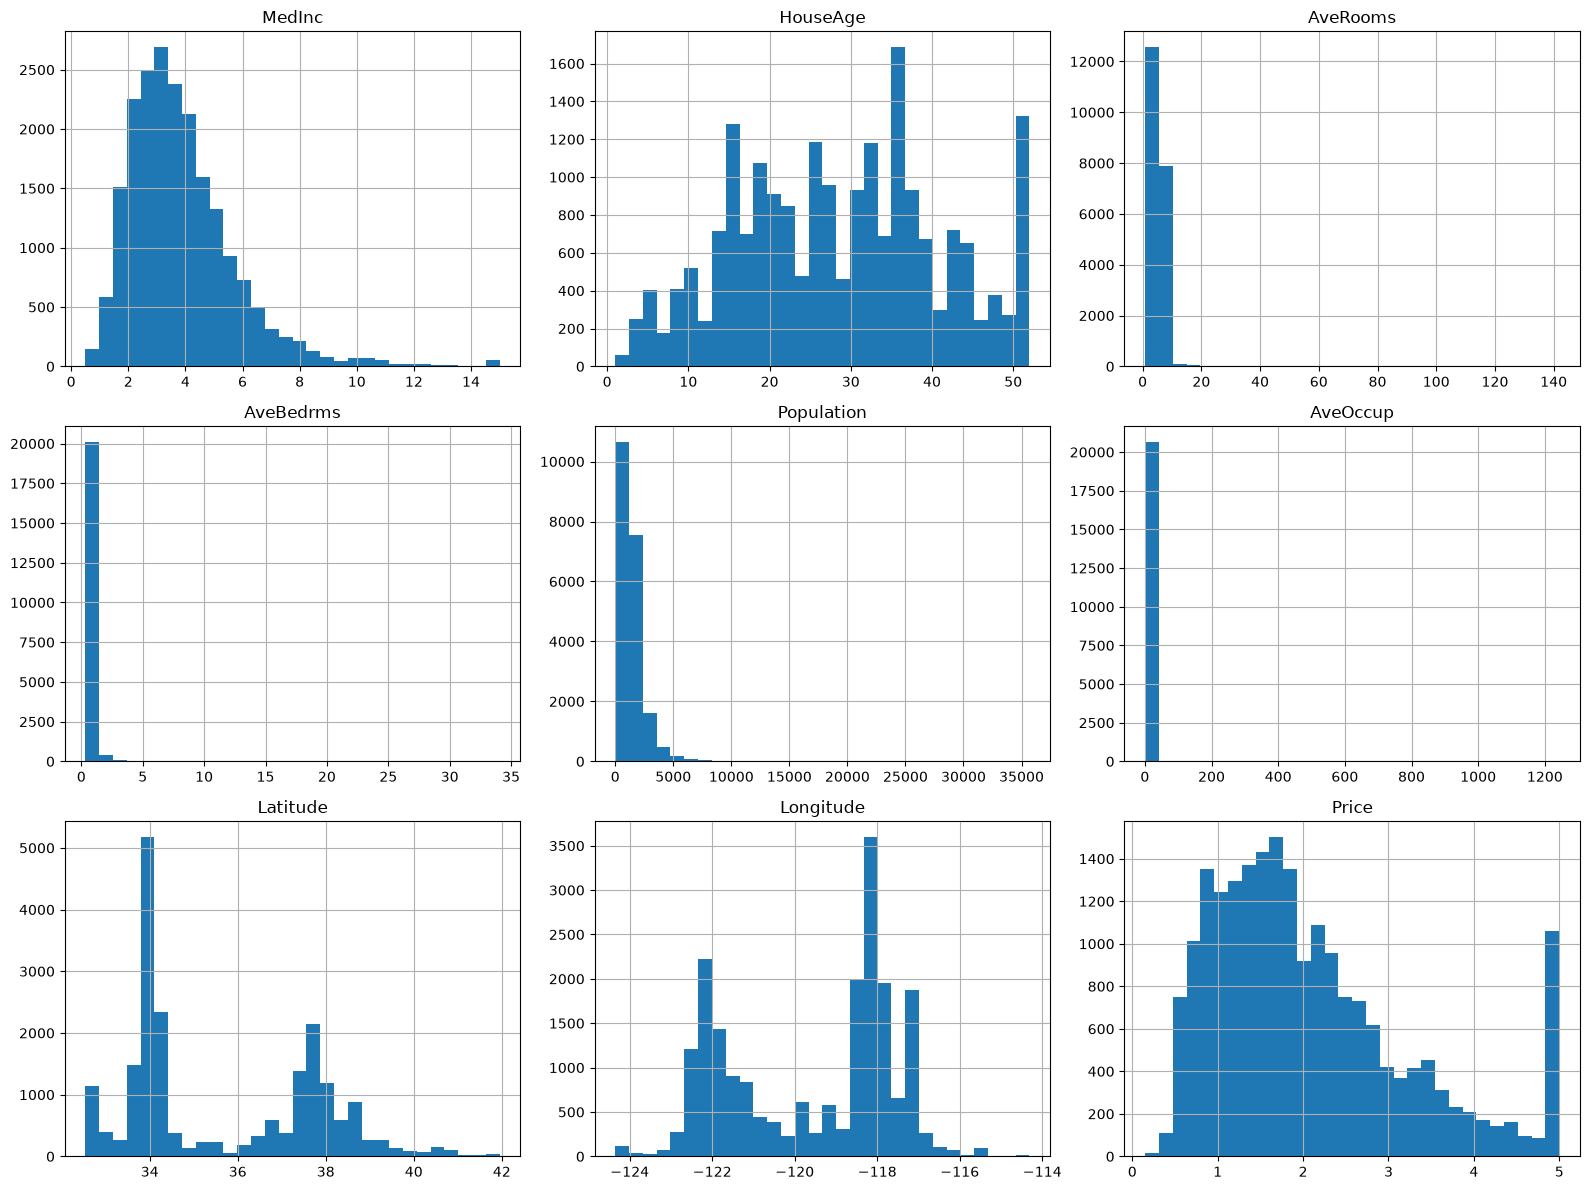

In [11]:
df.hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()

plt.show()

# Pairplot

A Pairplot visualizes relationships between variables.

It helps identify:

- Linear Relationships
- Clusters
- Outliers
- Feature Trends

Since the California Housing dataset contains many features, we will visualize a subset.

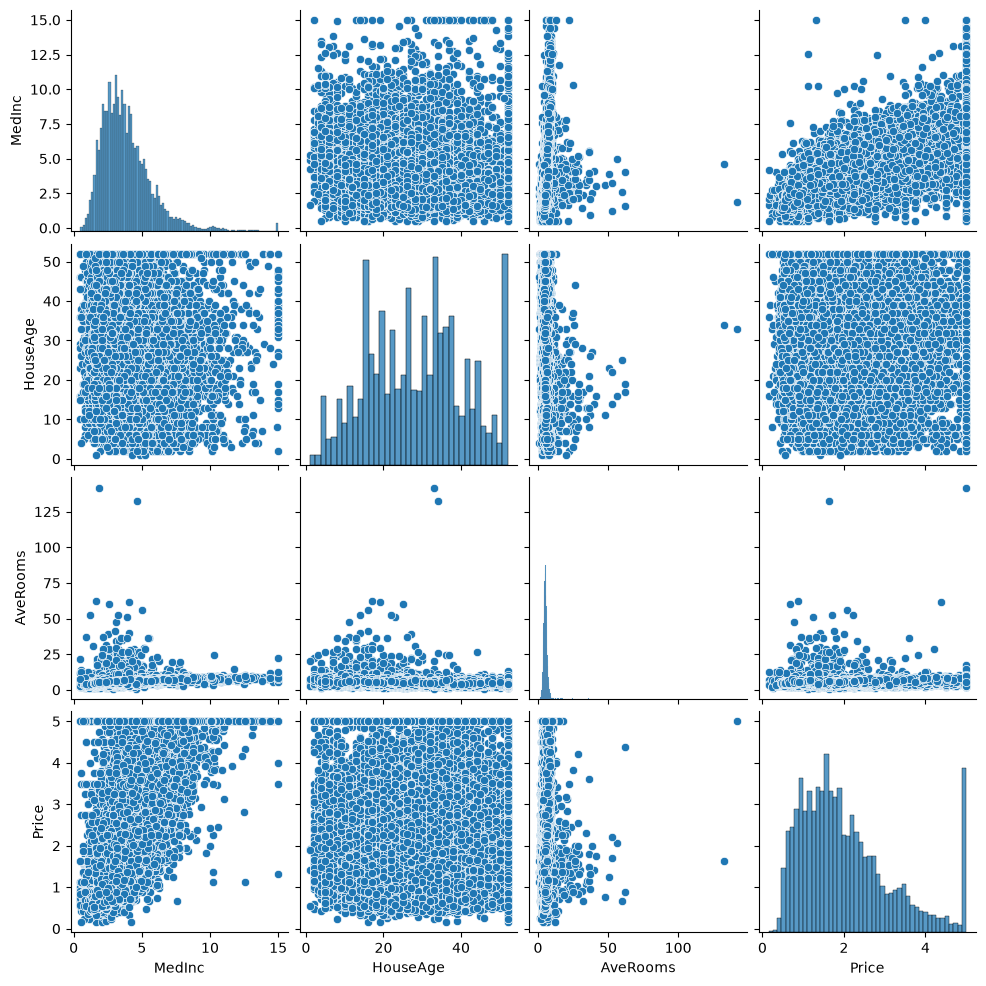

In [12]:
sample_columns = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Price"
]

sns.pairplot(df[sample_columns])

plt.show()

# Feature Selection

Machine Learning models learn from Features (Independent Variables).

The Target Variable is what we want to predict.

For this project:

Target Variable

Price

Input Features

All remaining columns

In [13]:
X = df.drop("Price", axis=1)

y = df["Price"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (20640, 8)
Target Shape : (20640,)


# Train-Test Split

Machine Learning models should never be evaluated using the same data they were trained on.

Therefore, we divide the dataset into:

Training Set (80%)

Testing Set (20%)

Training data teaches the model.

Testing data evaluates how well the model performs on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [15]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (16512, 8)
Testing Features : (4128, 8)
Training Labels : (16512,)
Testing Labels : (4128,)


# Feature Scaling

Feature Scaling standardizes numerical values so that every feature contributes equally during model training.

Without scaling:

- Large numerical values dominate smaller ones.
- Training becomes unstable.
- Some algorithms perform poorly.

We use StandardScaler to transform every feature into a standard scale.

Mean = 0

Standard Deviation = 1

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Building the Linear Regression Model

Now we train our first Machine Learning model.

Linear Regression tries to find the best straight line that minimizes prediction errors.

During training, the algorithm automatically learns:

- Slope (Coefficient)
- Intercept

using the Least Squares Method.

In [17]:
linear_model = LinearRegression()

linear_model.fit(

    X_train_scaled,

    y_train

)

print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


# Model Parameters

After training, the model learns:

Intercept

Represents the predicted value when every feature equals zero.

Coefficients

Represent how much the target changes when a feature increases by one unit while other variables remain constant.

In [18]:
print("Intercept")

print(linear_model.intercept_)

print()

print("Coefficients")

coefficients = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":linear_model.coef_

})

coefficients

Intercept
2.0719469373788777

Coefficients


,Feature,Coefficient
0,MedInc,0.854383
1,HouseAge,0.122546
2,AveRooms,-0.294410
3,AveBedrms,0.339259
4,Population,-0.002308
5,AveOccup,-0.040829
6,Latitude,-0.896929
7,Longitude,-0.869842


# Making Predictions

After training the model, we use the unseen testing data.

The model predicts house prices based on the learned relationship between features and target values.

In [19]:
y_pred = linear_model.predict(

    X_test_scaled

)

In [20]:
predictions = pd.DataFrame({

    "Actual Price":y_test,

    "Predicted Price":y_pred

})

predictions.head(10)

,Actual Price,Predicted Price
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


# Regression Evaluation Metrics

Regression models are evaluated using numerical error metrics.

The four most common metrics are:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine how accurately the model predicts unseen data.

In [21]:
mae = mean_absolute_error(

    y_test,

    y_pred

)

mse = mean_squared_error(

    y_test,

    y_pred

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    y_pred
)

metrics = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE",

        "R² Score"

    ],

    "Value":[

        mae,

        mse,

        rmse,

        r2

    ]

})

metrics

,Metric,Value
0,MAE,0.533200
1,MSE,0.555892
2,RMSE,0.745581
3,R² Score,0.575788


# Saving Evaluation Results

To keep a record of model performance, we save the evaluation metrics as a CSV file.

This file can later be included in project reports, dashboards, or GitHub repositories.

In [22]:
metrics.to_csv(

    "../outputs/regression_metrics.csv",

    index=False

)

print("Regression metrics saved successfully.")

Regression metrics saved successfully.


# Model Visualization

Model evaluation is incomplete without visualization.

Graphs help us understand:

- How close predictions are to actual values.
- Whether the model is making systematic errors.
- Whether the model is overfitting or underfitting.

In this section, we will create visualizations to evaluate our Linear Regression model.

# Actual vs Predicted Values

This scatter plot compares the actual house prices with the predicted house prices.

If the model performs well, the points should lie close to the diagonal line.

The closer the points are to the line, the better the model's predictions.

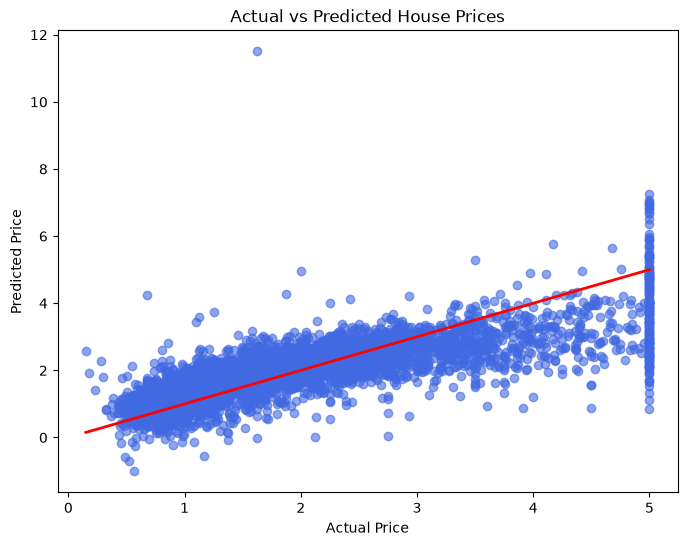

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("../images/actual_vs_predicted.png")

plt.show()

# Observation

The scatter plot indicates how accurately the Linear Regression model predicts house prices.

A perfect model would place every point exactly on the red diagonal line.

Points farther away from the line indicate prediction errors.

# Residual Analysis

Residuals represent the difference between actual and predicted values.

Residual = Actual − Predicted

A good regression model should produce residuals that are randomly distributed around zero.

Patterns in residuals may indicate that the model is missing important relationships.

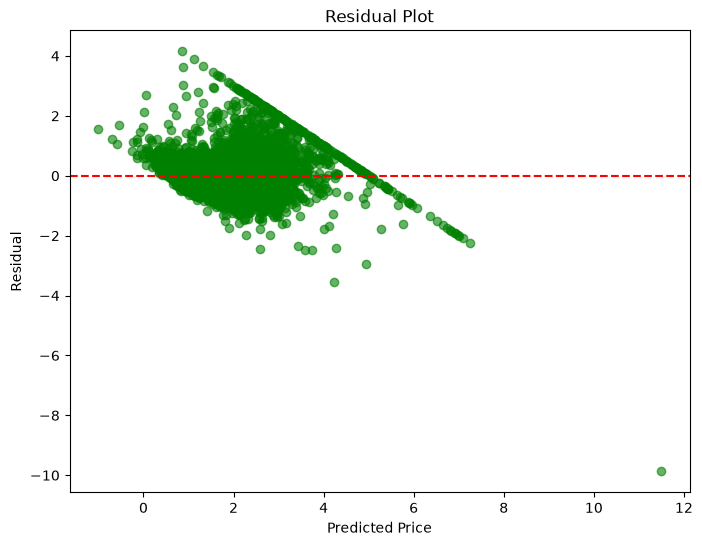

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color="green"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.savefig("../images/residual_plot.png")

plt.show()

# Understanding Polynomial Regression

Linear Regression can only learn straight-line relationships.

However, many real-world datasets have curved relationships.

Polynomial Regression solves this problem by creating additional polynomial features such as:

- x²
- x³
- x⁴

This allows Linear Regression to model nonlinear patterns.

In [25]:
poly_model = Pipeline([

    ("poly", PolynomialFeatures(degree=2)),

    ("linear", LinearRegression())

])

In [26]:
poly_model.fit(
    X_train_scaled,
    y_train
)

print("Polynomial Regression Model Trained Successfully.")

Polynomial Regression Model Trained Successfully.


# Polynomial Regression Prediction

Now we will use the trained Polynomial Regression model to predict the prices of unseen houses.

In [27]:
poly_predictions = poly_model.predict(
    X_test_scaled
)

# Polynomial Regression Evaluation

We evaluate the Polynomial Regression model using the same metrics used for Linear Regression.

This allows us to compare both models fairly.

In [28]:
poly_mae = mean_absolute_error(
    y_test,
    poly_predictions
)

poly_mse = mean_squared_error(
    y_test,
    poly_predictions
)

poly_rmse = np.sqrt(poly_mse)

poly_r2 = r2_score(
    y_test,
    poly_predictions
)

print("MAE :", poly_mae)
print("MSE :", poly_mse)
print("RMSE :", poly_rmse)
print("R² :", poly_r2)

MAE : 0.46700093346965704
MSE : 0.46430152383011647
RMSE : 0.6813967448044616
R² : 0.6456819729261949


# Model Comparison

A comparison table helps us decide which model performs better.

Lower MAE, MSE and RMSE values indicate fewer prediction errors.

Higher R² Score indicates a better fit to the data.

In [29]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Polynomial Regression"

    ],

    "MAE":[

        mae,

        poly_mae

    ],

    "RMSE":[

        rmse,

        poly_rmse

    ],

    "R² Score":[

        r2,

        poly_r2

    ]

})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Polynomial Regression,0.467001,0.681397,0.645682


In [30]:
comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Comparison file saved successfully.")

Comparison file saved successfully.


# Final Results

After comparing both models, we can determine which regression algorithm performs better on the California Housing dataset.

In many cases, Polynomial Regression captures nonlinear relationships more effectively than Linear Regression.

However, increasing the polynomial degree too much may lead to overfitting.

Therefore, selecting an appropriate degree is very important.

# Conclusion

In this notebook, we successfully implemented two supervised machine learning regression algorithms.

We learned how to:

- Load a regression dataset
- Perform Exploratory Data Analysis
- Train a Linear Regression model
- Train a Polynomial Regression model
- Evaluate model performance using MAE, MSE, RMSE, and R² Score
- Visualize predictions using scatter plots
- Analyze residual errors
- Compare two regression models

This practical provided a strong foundation for solving real-world regression problems using Scikit-Learn.

# Key Learnings

- Difference between Supervised Learning and Regression
- Working of Linear Regression
- Working of Polynomial Regression
- Feature Scaling
- Model Training
- Model Prediction
- Regression Evaluation Metrics
- Scatter Plot Interpretation
- Residual Analysis
- Model Comparison